In [1]:
import pandas as pd;

In [2]:
df=pd.read_csv("C:\\Users\91912\\Downloads\\Titanic-Dataset.csv")

In [3]:
df.shape

(891, 12)

In [4]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


DATA CLEANING
removing null values

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df=df.drop("Cabin",axis=1)

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [10]:
df["Age"].skew()

np.float64(0.38910778230082704)

In [11]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [12]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

In [13]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [14]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

DUPLICATE VALUES

In [15]:
print(df.duplicated().sum())

0


outlier analysis

In [16]:
import numpy as np

In [17]:
a=df.select_dtypes(include=np.number)

In [18]:
import seaborn as sns

<Axes: >

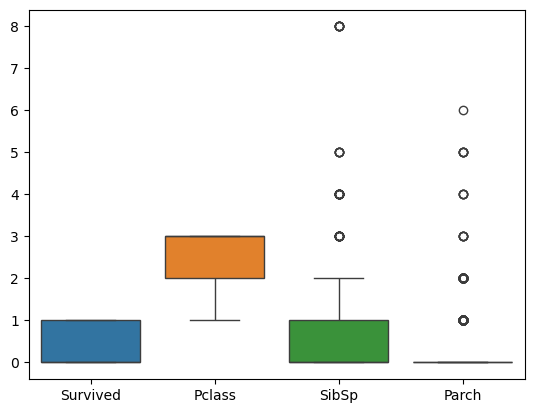

In [19]:
sns.boxplot([df["Survived"],df["Pclass"],df["SibSp"],df["Parch"]])

In [20]:
for i in a:
    q1=a[i].quantile(0.25)
    q2=a[i].quantile(0.50)
    q3=a[i].quantile(0.75)

In [21]:
IQR=q3-q1

In [22]:
Uw=q3+1.5*IQR
Lw=q1-1.5*IQR

In [23]:
outliers=((a[i]>Uw)|(a[i]<Lw))

In [24]:
print(outliers.sum())


116


In [25]:
a.loc[(a[i]>Uw)|(a[i]<Lw)]

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
1,2,1,1,38.000000,1,0,71.2833
27,28,0,1,19.000000,3,2,263.0000
31,32,1,1,29.699118,1,0,146.5208
34,35,0,1,28.000000,1,0,82.1708
52,53,1,1,49.000000,1,0,76.7292
...,...,...,...,...,...,...,...
846,847,0,3,29.699118,8,2,69.5500
849,850,1,1,29.699118,1,0,89.1042
856,857,1,1,45.000000,1,1,164.8667
863,864,0,3,29.699118,8,2,69.5500


DATA ANALYSIS

In [26]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [27]:
print(df["PassengerId"].count())

891


There are 891 passengers present in ship

In [28]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

most of people died in incident

In [29]:
df.groupby("Sex")["Survived"].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

most of female survived in the incident Binning

In [30]:
bins=[0,18,40,70]
labels=["Child","Adult","Old"]
df["Agegroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [31]:
c=df.groupby("Agegroup")["Survived"].mean()*100

C:\Users\91912\AppData\Local\Temp\ipykernel_9236\3146451615.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c=df.groupby("Agegroup")["Survived"].mean()*100


childrens are surviving more in the incident

In [32]:
d=df.groupby("Pclass")["Survived"].mean()*100

In [33]:
#most of people are survived from passenger class 1
df.sort_values(by="Fare",ascending=False).head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Agegroup
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,Adult
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,Adult
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,Adult
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,S,Adult
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S,Adult


people who is paying more is survivng more

data visualiation

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

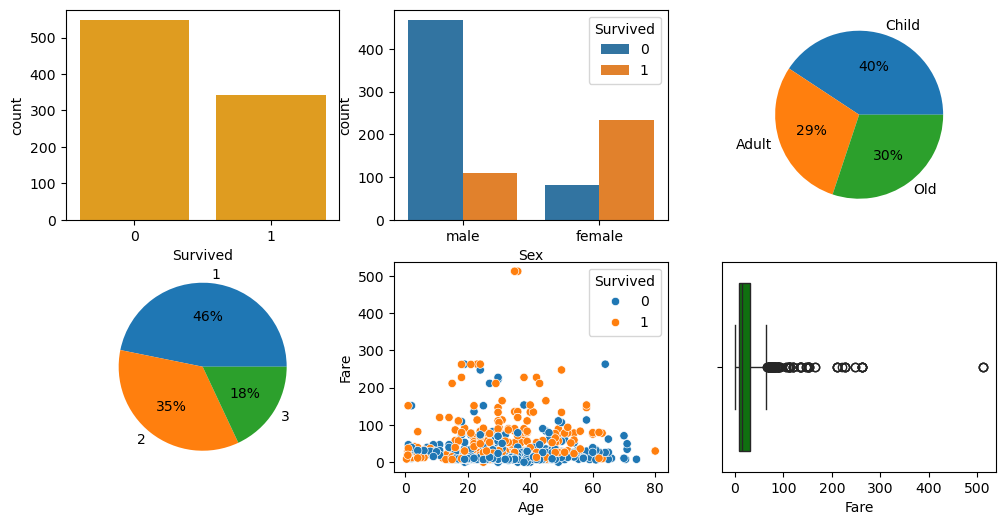

In [35]:
plt.figure(figsize=(12,6))
plt.subplot(2,3,1)
sns.countplot(x="Survived",data=df,color="Orange")
plt.subplot(2,3,2)
sns.countplot(x="Sex",hue="Survived",data=df)
plt.subplot(2,3,3)
plt.pie(c.values,labels=c.index,autopct="%1d%%")
plt.subplot(2,3,4)
plt.pie(d.values,labels=d.index,autopct="%1d%%")
plt.subplot(2,3,5)
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.subplot(2,3,6)
sns.boxplot(x="Fare",data=df,color="Green")
plt.show()

### 1 Most of the people died in the incident
### 2 Most of the female survived in the incident
### 3 Most of the child survived in the incident
### 4 Passenger from class 1 survived more in the incident
### 5 The passenger who is paying more fare are surviving more in the incident
### 6 Around 20 people paying more than average in the incident

In [36]:
###thank u